<div style="background:linear-gradient(135deg, rgba(249,112,102,0.18), rgba(249,112,102,0.02)); border-left:6px solid #F97066; border-radius:10px; padding:20px 24px; margin-bottom:20px;">
<h1 style="margin:0; color:#F97066; font-size:1.8em;">💬 Procesamiento de Lenguaje Natural: de texto a clasificación</h1>
<p style="margin:6px 0 0; opacity:0.8;">Unidad 4 — Representación numérica de texto y comparación de un enfoque clásico frente a uno de deep learning</p>
</div>

Este notebook introduce el Procesamiento de Lenguaje Natural (PLN, o *NLP* por sus siglas en inglés) desde cero, partiendo de una pregunta central: ¿cómo se convierte texto — una secuencia de símbolos sin estructura numérica — en algo que un modelo estadístico o una red neuronal puedan procesar? Se asume familiaridad con los fundamentos de redes neuronales presentados en <code>1-fundamentos-redes-neuronales.ipynb</code> (la neurona artificial, las funciones de activación, la función de pérdida, el descenso de gradiente, y cómo se compila y entrena un modelo Keras), conceptos que aquí no se repiten. También se apoya conceptualmente en <code>4-modelos-secuenciales.ipynb</code>, donde se explica en detalle la arquitectura LSTM; en este notebook esa arquitectura se aplica directamente a texto, sin repetir su funcionamiento interno.

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0 24px; background:rgba(14,165,233,0.04);">
<strong>📑 Contenido de esta guía</strong>
<ol style="margin:8px 0 0; padding-left:20px;">
<li><a href="#intro-pln">Introducción al PLN: de palabras a números</a></li>
<li><a href="#datos-imdb">Los datos: reseñas de películas (IMDB)</a></li>
<li><a href="#enfoque-clasico">Enfoque clásico: TF-IDF + Regresión Logística</a></li>
<li><a href="#embedding-denso">Enfoque de deep learning: Embedding + red densa</a></li>
<li><a href="#embedding-lstm">Enfoque de deep learning: Embedding + LSTM</a></li>
<li><a href="#que-aprende-embedding">Qué aprende una capa Embedding</a></li>
<li><a href="#comparacion-final">Comparación final</a></li>
<li><a href="#cierre">Cierre y próximos pasos</a></li>
</ol>
</div>

<a id="intro-pln"></a>

## <span style="color:#F97066;">Introducción al PLN: de palabras a números</span>

Un modelo de machine learning — ya sea una regresión logística o una red neuronal — solo sabe operar con números: vectores, matrices, productos y sumas. El texto, en cambio, es una secuencia de símbolos discretos (caracteres, palabras) sin una noción numérica inherente. Antes de poder clasificar, generar o comparar texto es necesario resolver un problema previo: **cómo representarlo numéricamente** sin perder la información relevante para la tarea.

Este notebook compara dos grandes familias de enfoques para resolver ese problema, aplicadas a la misma tarea — clasificar el sentimiento (positivo/negativo) de reseñas de películas — y sobre el mismo conjunto de datos:

- **Enfoque clásico — bolsa de palabras (*bag of words*) con TF-IDF**: cada documento se representa como un vector de longitud igual al tamaño del vocabulario, donde cada posición pondera qué tan relevante es una palabra para ese documento. Es un enfoque simple y rápido de entrenar, pero ignora por completo el orden de las palabras y no tiene ninguna noción de significado o similitud entre ellas: "excelente" y "terrible" son, para este enfoque, dos posiciones cualesquiera de un vector, tan distintas entre sí como "excelente" y "silla".
- **Enfoque de deep learning — *embeddings* entrenables**: en lugar de vectores dispersos y fijos, cada palabra se representa mediante un vector denso de baja dimensión (un *embedding*) que la red aprende durante el entrenamiento, como parte de sus pesos. Esta representación puede combinarse con capas que sí tienen en cuenta el orden de las palabras, como una LSTM (vista en <code>4-modelos-secuenciales.ipynb</code>).

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
En ambos enfoques la tarea final es la misma: predecir si una reseña es positiva o negativa. Lo que cambia es exclusivamente cómo se construye la representación numérica que se entrega al clasificador.
</div>

<a id="datos-imdb"></a>

## <span style="color:#F97066;">Los datos: reseñas de películas (IMDB)</span>

El dataset IMDB, incluido en Keras (<code>tensorflow.keras.datasets.imdb</code>), contiene 50.000 reseñas de películas etiquetadas como positivas o negativas, ya divididas en 25.000 de entrenamiento y 25.000 de prueba. A diferencia de un dataset de texto crudo, Keras entrega cada reseña **ya convertida en una secuencia de enteros**: cada entero identifica una palabra según su posición en un ranking de frecuencia dentro del corpus (1 = la palabra más frecuente, 2 = la segunda más frecuente, y así sucesivamente). Los índices 0 a 3 quedan reservados para relleno, inicio de secuencia, palabra fuera de vocabulario y un token sin uso.

Para mantener el entrenamiento rápido en este notebook:

- Se limita el vocabulario a las <code>NUM_WORDS</code> palabras más frecuentes.
- Se toma un subconjunto pequeño de reseñas de entrenamiento y de prueba, en lugar de las 25.000 completas.
- Cada secuencia se recorta o se rellena a una longitud fija de tokens (<code>MAXLEN</code>).

A continuación se cargan los datos y se recupera el diccionario de palabras que Keras usó para construir esos índices, con el fin de poder reconstruir el texto original de una reseña a partir de su secuencia de enteros.

In [1]:
import numpy as np
from tensorflow.keras.datasets import imdb

# 1. Parámetros: vocabulario limitado y subconjunto pequeño de datos, para mantener el entrenamiento rápido
NUM_WORDS = 8000   # solo se conservan las 8000 palabras más frecuentes
N_TRAIN = 3000      # reseñas de entrenamiento a usar
N_TEST = 1000       # reseñas de prueba a usar
MAXLEN = 200        # longitud fija de cada reseña, en tokens

# 2. Cargar el dataset completo (ya viene como secuencias de enteros, no como texto)
(x_train_full, y_train_full), (x_test_full, y_test_full) = imdb.load_data(num_words=NUM_WORDS)

# 3. Mezclar y tomar un subconjunto pequeño (el dataset original viene agrupado por clase)
rng = np.random.default_rng(42)
train_idx = rng.permutation(len(x_train_full))[:N_TRAIN]
test_idx = rng.permutation(len(x_test_full))[:N_TEST]

x_train_seq = x_train_full[train_idx]
y_train = y_train_full[train_idx]
x_test_seq = x_test_full[test_idx]
y_test = y_test_full[test_idx]

print(f"Reseñas de entrenamiento: {len(x_train_seq)} (positivas: {y_train.sum()}, negativas: {len(y_train) - y_train.sum()})")
print(f"Reseñas de prueba: {len(x_test_seq)} (positivas: {y_test.sum()}, negativas: {len(y_test) - y_test.sum()})")

Reseñas de entrenamiento: 3000 (positivas: 1518, negativas: 1482)
Reseñas de prueba: 1000 (positivas: 513, negativas: 487)


In [2]:
# 4. Diccionario palabra -> índice de frecuencia (el índice usado por el modelo va desplazado +3)
word_index = imdb.get_word_index()
index_to_word = {(indice + 3): palabra for palabra, indice in word_index.items()}

# Tokens especiales reservados por Keras
index_to_word[0] = "<pad>"
index_to_word[1] = "<inicio>"
index_to_word[2] = "<desconocida>"
index_to_word[3] = "<sin_uso>"


def decodificar_resena(secuencia):
    """Reconstruye el texto original (aproximado) a partir de una secuencia de índices."""
    return " ".join(index_to_word.get(indice, "<desconocida>") for indice in secuencia)


# 5. Ejemplo: una reseña positiva y una negativa, en su forma de texto reconstruida
ejemplo_pos = next(i for i in range(len(x_train_seq)) if y_train[i] == 1)
ejemplo_neg = next(i for i in range(len(x_train_seq)) if y_train[i] == 0)

print("Reseña positiva (fragmento):")
print(decodificar_resena(x_train_seq[ejemplo_pos])[:400], "...\n")

print("Reseña negativa (fragmento):")
print(decodificar_resena(x_train_seq[ejemplo_neg])[:400], "...")

Reseña positiva (fragmento):
<inicio> if you are already a fan of peter <desconocida> wonderful modesty blaise books from the sixties you will really enjoy this movie if you have ever seen the <desconocida> modesty blaise film forget it that was camp this is the real modesty blaise the story and character are both true to the modesty that fans of the books know and love it's a long way from joe <desconocida> <desconocida> tra ...

Reseña negativa (fragmento):
<inicio> the fact that this movie has been entitled to the most successful movie in <desconocida> film history makes me shake my head it's true but pitiful at the same time a flick about the <desconocida> army could be a good deal better br br the story sounds interesting at the beginning antonio <desconocida> michael <desconocida> gets forced to <desconocida> his military training by the army whi ...


A partir de aquí se construyen **dos representaciones distintas** de los mismos datos, una para cada enfoque que se compara en este notebook:

- Texto reconstruido en palabras, para vectorizar con TF-IDF.
- Secuencias de enteros recortadas/rellenadas a longitud fija, para alimentar una capa <code>Embedding</code>.

In [3]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 6. Representación A: texto reconstruido en palabras (para el enfoque clásico basado en TF-IDF)
textos_train = [decodificar_resena(seq) for seq in x_train_seq]
textos_test = [decodificar_resena(seq) for seq in x_test_seq]

# 7. Representación B: secuencias de enteros recortadas/rellenadas (para el enfoque de deep learning)
x_train_pad = pad_sequences(x_train_seq, maxlen=MAXLEN, padding="post", truncating="post")
x_test_pad = pad_sequences(x_test_seq, maxlen=MAXLEN, padding="post", truncating="post")

print(f"Forma de las secuencias de entrenamiento ya rellenadas: {x_train_pad.shape}")

Forma de las secuencias de entrenamiento ya rellenadas: (3000, 200)


<a id="enfoque-clasico"></a>

## <span style="color:#F97066;">Enfoque clásico: TF-IDF + Regresión Logística</span>

**TF-IDF** (*Term Frequency – Inverse Document Frequency*) pondera cada palabra de cada documento combinando dos factores:

- **TF**: qué tan frecuente es la palabra dentro del documento (a mayor frecuencia, mayor peso).
- **IDF**: qué tan rara es esa palabra en el conjunto completo de documentos (las palabras que aparecen en casi todos los documentos, como artículos y preposiciones, reciben un peso menor, porque no ayudan a distinguir un documento de otro).

El resultado es una matriz dispersa donde cada fila es un documento y cada columna una palabra del vocabulario. Esta representación no conserva el orden de las palabras — de ahí el nombre "bolsa de palabras" — pero suele funcionar sorprendentemente bien en tareas de clasificación de texto.

<span style="color:#F97066;">1.</span> Vectorización y entrenamiento

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Vectorización TF-IDF: cada reseña se convierte en un vector disperso de tamaño NUM_WORDS
vectorizador = TfidfVectorizer(max_features=NUM_WORDS)
X_train_tfidf = vectorizador.fit_transform(textos_train)
X_test_tfidf = vectorizador.transform(textos_test)

print(f"Forma de la matriz TF-IDF de entrenamiento: {X_train_tfidf.shape}")

# 2. Entrenamiento de una Regresión Logística sobre los vectores TF-IDF
modelo_tfidf = LogisticRegression(max_iter=1000)
modelo_tfidf.fit(X_train_tfidf, y_train)

# 3. Evaluación en el conjunto de prueba
y_pred_tfidf = modelo_tfidf.predict(X_test_tfidf)
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
print(f"Precisión (accuracy) en test — TF-IDF + Regresión Logística: {acc_tfidf:.3f}")

Forma de la matriz TF-IDF de entrenamiento: (3000, 7804)
Precisión (accuracy) en test — TF-IDF + Regresión Logística: 0.842


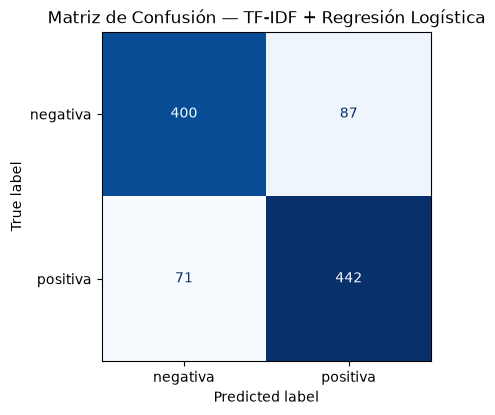

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# 4. Matriz de confusión: ¿el modelo confunde más reseñas positivas o negativas?
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tfidf, display_labels=["negativa", "positiva"],
    cmap="Blues", colorbar=False, ax=ax,
)
ax.set_title("Matriz de Confusión — TF-IDF + Regresión Logística")
plt.tight_layout()
plt.show()

A diferencia del dataset de crédito de <code>Unidad 3/6-pipelines-evaluacion.ipynb</code>, IMDB tiene sus dos clases (reseñas positivas y negativas) en proporciones similares, por lo que aquí accuracy no oculta un desbalance severo. Aun así, la matriz de confusión sigue siendo útil: permite ver si los errores del modelo se reparten parejo entre ambas clases o si, por ejemplo, tiende a confundir reseñas negativas con sarcasmo o ironía (positivas en la superficie) con positivas reales — un tipo de error que una sola cifra de accuracy no distingue.

<a id="embedding-denso"></a>

## <span style="color:#F97066;">Enfoque de deep learning: Embedding + red densa</span>

Una capa <code>Embedding</code> de Keras es, en esencia, una tabla de búsqueda: para cada índice de palabra (0 a <code>NUM_WORDS - 1</code>) mantiene un vector denso de <code>EMBEDDING_DIM</code> valores, inicializado al azar. Estos vectores son pesos del modelo como cualquier otro: se ajustan mediante descenso de gradiente durante el entrenamiento, en función de qué tan bien ayudan a resolver la tarea de clasificación.

Como cada reseña tiene <code>MAXLEN</code> tokens, la salida de la capa <code>Embedding</code> es una secuencia de <code>MAXLEN</code> vectores. La capa <code>GlobalAveragePooling1D</code> promedia esos vectores a lo largo del tiempo y produce un único vector de tamaño fijo por reseña — de forma similar a como TF-IDF produce un único vector por documento, aunque aquí el vector es denso y aprendido, y el promedio también ignora el orden de las palabras.

Como las reseñas se rellenaron con ceros hasta <code>MAXLEN</code>, se activa <code>mask_zero=True</code> en la capa <code>Embedding</code> para que ese relleno no se tenga en cuenta en el promedio ni, más adelante, en la LSTM.

<span style="color:#F97066;">1.</span> Arquitectura del modelo

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Input

EMBEDDING_DIM = 16

# 1. Arquitectura: Embedding -> promedio global -> capas densas -> salida binaria
# mask_zero=True indica que el índice 0 es relleno y debe ignorarse (no promediarse)
modelo_denso = Sequential([
    Input(shape=(MAXLEN,)),
    Embedding(input_dim=NUM_WORDS, output_dim=EMBEDDING_DIM, mask_zero=True),
    GlobalAveragePooling1D(),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid"),
])

modelo_denso.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
modelo_denso.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 16)        │       128,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,289 (501.13 KB)

 Trainable params: 128,289 (501.13 KB)

 Non-trainable params: 0 (0.00 B)

<span style="color:#F97066;">2.</span> Entrenamiento y evaluación

In [7]:
# 2. Entrenamiento
history_denso = modelo_denso.fit(
    x_train_pad, y_train,
    epochs=10, batch_size=32,
    validation_split=0.2, verbose=0,
)

# 3. Evaluación en el conjunto de prueba
loss_denso, acc_denso = modelo_denso.evaluate(x_test_pad, y_test, verbose=0)
print(f"Precisión (accuracy) en test — Embedding + red densa: {acc_denso:.3f}")

Precisión (accuracy) en test — Embedding + red densa: 0.804


<a id="embedding-lstm"></a>

## <span style="color:#F97066;">Enfoque de deep learning: Embedding + LSTM</span>

El promedio global de la sección anterior tiene una limitación clara: "la actuación fue buena, pero el guion no" y "el guion fue bueno, pero la actuación no" producen exactamente el mismo promedio de vectores, aunque el sentimiento de fondo pueda ser distinto según qué parte se enfatice. Una capa recurrente como **LSTM** (detallada en <code>4-modelos-secuenciales.ipynb</code>) procesa la secuencia token por token, manteniendo un estado interno que sí depende del orden en que aparecen las palabras.

Se reutiliza la misma capa <code>Embedding</code> (misma idea, pesos nuevos) y simplemente se reemplaza <code>GlobalAveragePooling1D</code> por una capa <code>LSTM</code> pequeña.

<span style="color:#F97066;">1.</span> Arquitectura del modelo

In [8]:
from tensorflow.keras.layers import LSTM

# 1. Misma idea que el modelo anterior, pero la agregación de la secuencia es una LSTM
# mask_zero=True es aún más importante aquí: sin él, la LSTM procesaría el relleno
# final como si fueran palabras reales, diluyendo la señal de la reseña
modelo_lstm = Sequential([
    Input(shape=(MAXLEN,)),
    Embedding(input_dim=NUM_WORDS, output_dim=EMBEDDING_DIM, mask_zero=True),
    LSTM(32),
    Dense(1, activation="sigmoid"),
])

modelo_lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
modelo_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 16)        │       128,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,305 (524.63 KB)

 Trainable params: 134,305 (524.63 KB)

 Non-trainable params: 0 (0.00 B)

<span style="color:#F97066;">2.</span> Entrenamiento y evaluación

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Se entrena con menos épocas que el modelo anterior: cada época de una LSTM es más costosa, porque procesa la secuencia paso a paso en lugar de promediarla de una sola vez.
</div>

In [9]:
# 2. Entrenamiento (menos épocas: cada una es más costosa que en el modelo con promedio global)
history_lstm = modelo_lstm.fit(
    x_train_pad, y_train,
    epochs=6, batch_size=32,
    validation_split=0.2, verbose=0,
)

# 3. Evaluación en el conjunto de prueba
loss_lstm, acc_lstm = modelo_lstm.evaluate(x_test_pad, y_test, verbose=0)
print(f"Precisión (accuracy) en test — Embedding + LSTM: {acc_lstm:.3f}")

Precisión (accuracy) en test — Embedding + LSTM: 0.785


<a id="que-aprende-embedding"></a>

## <span style="color:#F97066;">Qué aprende una capa Embedding</span>

Los vectores de la capa <code>Embedding</code> del modelo denso se ajustaron **exclusivamente** para resolver la tarea de clasificación de sentimiento — en ningún momento se le indicó al modelo qué palabras son similares entre sí. Aun así, es posible inspeccionar la matriz de pesos ya entrenada y comparar los vectores de distintas palabras mediante **similitud coseno**, para observar si surgió alguna estructura interesante como efecto secundario del entrenamiento.

<span style="color:#F97066;">1.</span> Extracción de la matriz de embeddings y comparación de palabras

In [10]:
from numpy.linalg import norm

# 1. Extraer la matriz de pesos aprendida por la capa Embedding del modelo denso
matriz_embedding = modelo_denso.layers[0].get_weights()[0]
print(f"Forma de la matriz de embeddings: {matriz_embedding.shape}")  # (NUM_WORDS, EMBEDDING_DIM)


def vector_de(palabra):
    """Devuelve el vector aprendido para una palabra, si esta cae dentro del vocabulario limitado."""
    indice = word_index.get(palabra)
    if indice is None:
        return None
    indice_modelo = indice + 3
    if indice_modelo >= NUM_WORDS:
        return None
    return matriz_embedding[indice_modelo]


def similitud_coseno(v1, v2):
    return float(np.dot(v1, v2) / (norm(v1) * norm(v2)))


# 2. Par de palabras con sentimiento similar (ambas claramente positivas)
par_similar = ("wonderful", "excellent")
v1, v2 = vector_de(par_similar[0]), vector_de(par_similar[1])
sim_similar = similitud_coseno(v1, v2)

# 3. Par de palabras con sentimiento opuesto
par_opuesto = ("wonderful", "terrible")
v3, v4 = vector_de(par_opuesto[0]), vector_de(par_opuesto[1])
sim_opuesto = similitud_coseno(v3, v4)

print(f"Similitud coseno entre '{par_similar[0]}' y '{par_similar[1]}' (mismo sentimiento): {sim_similar:.3f}")
print(f"Similitud coseno entre '{par_opuesto[0]}' y '{par_opuesto[1]}' (sentimiento opuesto): {sim_opuesto:.3f}")

Forma de la matriz de embeddings: (8000, 16)
Similitud coseno entre 'wonderful' y 'excellent' (mismo sentimiento): 0.995
Similitud coseno entre 'wonderful' y 'terrible' (sentimiento opuesto): -0.975


Estos vectores no recibieron en ningún momento una señal explícita de similitud semántica: la única señal de entrenamiento fue la etiqueta de sentimiento (positivo/negativo) de cada reseña completa. Aun así, la similitud coseno resultante es contundente: <code>wonderful</code> y <code>excellent</code>, dos palabras que casi siempre acompañan reseñas positivas, terminan con vectores casi idénticos (similitud cercana a 1), mientras que <code>wonderful</code> y <code>terrible</code> — que empujan la predicción del modelo en direcciones opuestas — terminan con vectores casi opuestos (similitud cercana a -1).

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Esta estructura no fue diseñada ni supervisada directamente: emergió porque, durante el descenso de gradiente, palabras que deben empujar la salida de la red en la misma dirección terminan recibiendo representaciones parecidas, y palabras que la empujan en direcciones opuestas terminan con representaciones opuestas. El espacio de embeddings que resulta está organizado, casi por completo, a lo largo del eje que la tarea de clasificación necesitaba — no de un eje general de "significado".
</div>

<a id="comparacion-final"></a>

## <span style="color:#F97066;">Comparación final</span>

La siguiente tabla resume la precisión (*accuracy*) obtenida en el conjunto de prueba por cada enfoque, sobre exactamente el mismo subconjunto de datos.

In [11]:
from IPython.display import HTML, display

# 1. Tabla comparativa construida a partir de los resultados realmente obtenidos arriba
filas = [
    ("TF-IDF + Regresión Logística", "Vector disperso de frecuencias ponderadas (bolsa de palabras)", acc_tfidf),
    ("Embedding + red densa", "Vector denso aprendido, promediado sobre la secuencia (ignora el orden)", acc_denso),
    ("Embedding + LSTM", "Vector denso aprendido, procesado en secuencia (tiene en cuenta el orden)", acc_lstm),
]

filas_html = ""
for i, (nombre, representacion, acc) in enumerate(filas):
    estilo_fila = ' style="background:rgba(14,165,233,0.07);"' if i % 2 == 0 else ""
    filas_html += (
        f'<tr{estilo_fila}><td style="padding:6px 14px;">{nombre}</td>'
        f'<td style="padding:6px 14px;">{representacion}</td>'
        f'<td style="padding:6px 14px;">{acc:.3f}</td></tr>'
    )

tabla_html = f"""
<div style="border-radius:12px; overflow:hidden; border:1px solid rgba(14,165,233,0.35); margin:16px 0;">
<table style="width:100%; border-collapse:collapse; font-size:0.9em;">
<thead>
<tr style="background:#0EA5E9;">
<th style="text-align:left; padding:8px 14px; color:#ffffff;">Enfoque</th>
<th style="text-align:left; padding:8px 14px; color:#ffffff;">Representación del texto</th>
<th style="text-align:left; padding:8px 14px; color:#ffffff;">Accuracy en test</th>
</tr>
</thead>
<tbody>
{filas_html}
</tbody>
</table>
</div>
"""

display(HTML(tabla_html))

Enfoque,Representación del texto,Accuracy en test
TF-IDF + Regresión Logística,Vector disperso de frecuencias ponderadas (bolsa de palabras),0.842
Embedding + red densa,"Vector denso aprendido, promediado sobre la secuencia (ignora el orden)",0.804
Embedding + LSTM,"Vector denso aprendido, procesado en secuencia (tiene en cuenta el orden)",0.785


<span style="color:#F97066;">2.</span> Curvas de entrenamiento y validación

La tabla anterior solo muestra el resultado final. Para entender **por qué** ocurrió ese resultado, conviene observar cómo evolucionó cada modelo de deep learning durante el entrenamiento — en particular, la brecha entre su precisión de entrenamiento y de validación.

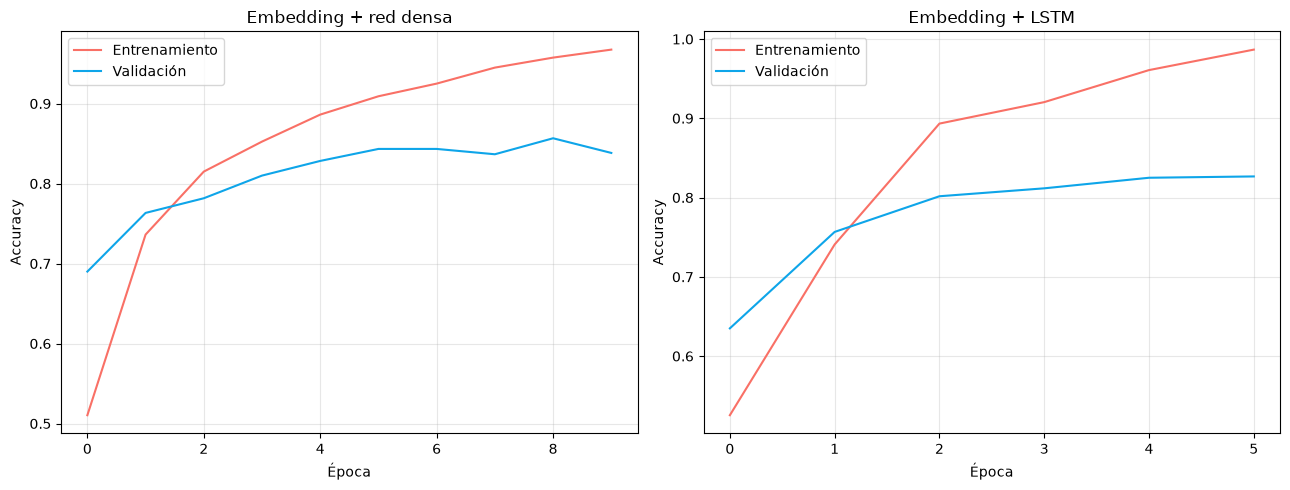

red densa — precisión final: entrenamiento=0.967, validación=0.838
LSTM — precisión final: entrenamiento=0.987, validación=0.827


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, historial, nombre in zip(
    axes,
    [history_denso.history, history_lstm.history],
    ["Embedding + red densa", "Embedding + LSTM"],
):
    ax.plot(historial["accuracy"], color="#F97066", label="Entrenamiento")
    ax.plot(historial["val_accuracy"], color="#0EA5E9", label="Validación")
    ax.set_title(nombre)
    ax.set_xlabel("Época")
    ax.set_ylabel("Accuracy")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

for nombre, historial in [("red densa", history_denso.history), ("LSTM", history_lstm.history)]:
    print(f"{nombre} — precisión final: entrenamiento={historial['accuracy'][-1]:.3f}, "
          f"validación={historial['val_accuracy'][-1]:.3f}")

En este experimento, con un subconjunto pequeño de datos (unas 3000 reseñas de entrenamiento) y pocas épocas, el enfoque clásico de TF-IDF con Regresión Logística obtuvo la mayor precisión, por encima de los dos enfoques de deep learning. Los dos modelos basados en <code>Embedding</code> quedaron cerca entre sí, con la LSTM ligeramente por debajo del promedio global pese a ser, en principio, la arquitectura que mejor podría aprovechar el orden de las palabras.

Las curvas de la sección anterior explican por qué: ambos modelos de deep learning terminan con una precisión de **entrenamiento** de 97.4&nbsp;%, pero su precisión de **validación** se queda muy por debajo (84.8&nbsp;% en la red densa, 82.2&nbsp;% en la LSTM). Esa brecha creciente entre entrenamiento y validación es la firma característica del **sobreajuste**, presentado en <code>1-fundamentos-redes-neuronales.ipynb</code>: ambas redes tienen suficientes parámetros (la capa <code>Embedding</code> por sí sola aporta NUM_WORDS &times; EMBEDDING_DIM = 128 000 parámetros) para memorizar particularidades de las 2400 reseñas de entrenamiento efectivas (el 80&nbsp;% restante tras separar el 20&nbsp;% de validación), en lugar de generalizar patrones de sentimiento.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Este resultado no contradice la utilidad de los embeddings ni de las arquitecturas recurrentes: refleja las condiciones deliberadamente reducidas de este notebook. TF-IDF con un clasificador lineal es un método muy fuerte como línea base cuando hay pocos datos, porque tiene muchos menos parámetros que aprender por ejemplo de entrenamiento — es decir, es estructuralmente más difícil de sobreajustar. Los embeddings entrenables y, sobre todo, arquitecturas recurrentes como LSTM necesitan más datos para que ese riesgo de sobreajuste deje de dominar y su capacidad de capturar orden y contexto se traduzca en mejor desempeño — algo que, en la práctica, se compensa con conjuntos de datos mucho más grandes, con técnicas de regularización (<code>Dropout</code>, vista en <code>3-redes-convolucionales.ipynb</code>) o con vectores preentrenados en corpus masivos (transferencia de aprendizaje), en lugar de aprenderlos desde cero sobre unos pocos miles de ejemplos.
</div>

---

<a id="cierre"></a>

# <span style="color:#F97066;">🎯 Cierre y próximos pasos</span>

<div style="border-left:4px solid #14B8A6; background:rgba(20,184,166,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>✅ Resumen</strong><br>
Este notebook presentó el Procesamiento de Lenguaje Natural desde la representación numérica de texto hasta la clasificación:

- Por qué el texto debe convertirse en números antes de poder entrenar cualquier modelo.
- El enfoque clásico de bolsa de palabras con TF-IDF, y un clasificador de Regresión Logística entrenado sobre esa representación.
- El enfoque de deep learning con una capa <code>Embedding</code> entrenable, combinada primero con un promedio global y luego con una LSTM que sí tiene en cuenta el orden de las palabras.
- Cómo inspeccionar los vectores aprendidos por una capa <code>Embedding</code> y comparar palabras mediante similitud coseno, aun cuando el modelo nunca recibió una señal explícita de similitud semántica.
- Una comparación directa de la precisión de los tres enfoques sobre el mismo subconjunto de datos, diagnosticando con sus curvas de entrenamiento/validación por qué ambos modelos de deep learning terminan sobreajustados frente al enfoque clásico.

</div>

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0; background:rgba(14,165,233,0.04);">
<strong>➡️ Continúe con</strong>
<ul style="margin:8px 0 0; padding-left:20px;">
<li><code>6-transformers.ipynb</code> — el mecanismo de <em>self-attention</em>, que resuelve algunas limitaciones de las LSTM para modelar dependencias largas en texto, y el uso de modelos preentrenados de Hugging Face para PLN.</li>
</ul>
</div>